# Cifra10

In [3]:
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

from tensorflow.keras.datasets import cifar10

from sklearn.model_selection import train_test_split

In [15]:
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [16]:
X_test,X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.2,stratify = y_test)

In [17]:
print(X_train.shape,X_test.shape,X_val.shape,y_train.shape,y_test.shape,y_val.shape)

(50000, 32, 32, 3) (8000, 32, 32, 3) (2000, 32, 32, 3) (50000, 1) (8000, 1) (2000, 1)


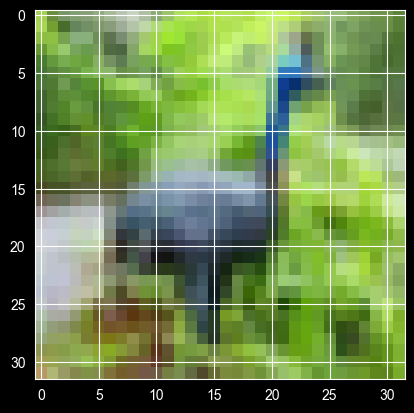

In [18]:
plt.imshow(X_train[6])

In [19]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

In [22]:
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu",name="bloc1_conv2d"),
    MaxPool2D(pool_size=(2,2),name="bloc1_pool2d"),

    Conv2D(filters=64,kernel_size=(3,3), padding="same", activation="relu",name="bloc2_conv2d"),
    MaxPool2D(pool_size=(2,2),name="bloc2_pool2d"),

    Flatten(name="flatten"),
    Dense(units=256,activation="relu",name="fc_1"),
    Dense(units=128,activation="relu",name="fc_2"),
    Dense(units=64,activation="relu",name="fc_3"),
    Dense(units=10,activation="softmax",name="fc_4")



])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bloc1_conv2d (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloc1_pool2d (MaxPooling2D)     │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloc2_conv2d (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloc2_pool2d (MaxPooling2D)     │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_4 (Dense)                    │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,110,026 (4.23 MB)

 Trainable params: 1,110,026 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras import callbacks
tensorboard = TensorBoard(log_dir='./logs', histogram_freq=0, write_graph=True, write_images=True)

In [31]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [32]:
history = model.fit(X_train,y_train, validation_data=(X_val,y_val), epochs=5, batch_size=32, callbacks=[tensorboard])

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4946 - loss: 1.3899 - val_accuracy: 0.6035 - val_loss: 1.1444
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6547 - loss: 0.9711 - val_accuracy: 0.6735 - val_loss: 0.9173
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7198 - loss: 0.7994 - val_accuracy: 0.7030 - val_loss: 0.8569
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7603 - loss: 0.6804 - val_accuracy: 0.7000 - val_loss: 0.8791
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8007 - loss: 0.5675 - val_accuracy: 0.7220 - val_loss: 0.8743


In [33]:
history = history.history

In [35]:
model.evaluate(X_test,y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7029 - loss: 0.9047


[0.9046546816825867, 0.702875018119812]

In [48]:
y_pred = model.predict(X_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
from sklearn.metrics import confusion_matrix,classification_report

In [52]:
y_pred=np.argmax(y_pred,axis=1)


In [53]:
y_pred

array([0, 1, 7, ..., 5, 5, 3], dtype=int64)

<Axes: >

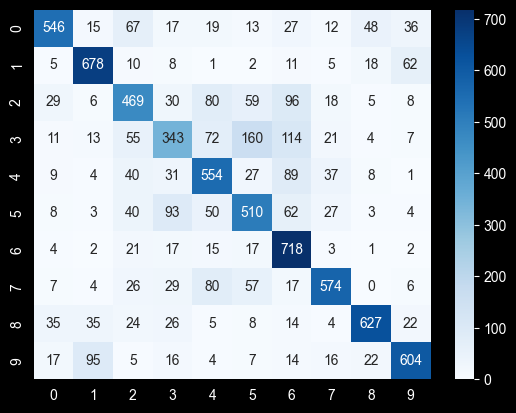

In [55]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="g",cmap="Blues")

In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.68      0.74       800
           1       0.79      0.85      0.82       800
           2       0.62      0.59      0.60       800
           3       0.56      0.43      0.49       800
           4       0.63      0.69      0.66       800
           5       0.59      0.64      0.61       800
           6       0.62      0.90      0.73       800
           7       0.80      0.72      0.76       800
           8       0.85      0.78      0.82       800
           9       0.80      0.76      0.78       800

    accuracy                           0.70      8000
   macro avg       0.71      0.70      0.70      8000
weighted avg       0.71      0.70      0.70      8000



In [57]:
np.where(y_test==8)

(array([  22,   35,   59,   82,  118,  127,  146,  151,  172,  189,  190,
         191,  204,  212,  228,  234,  237,  265,  267,  268,  284,  291,
         294,  314,  322,  331,  333,  335,  346,  355,  359,  361,  363,
         382,  384,  391,  398,  399,  426,  432,  451,  454,  471,  492,
         514,  522,  543,  559,  560,  561,  567,  576,  588,  593,  599,
         612,  622,  626,  629,  644,  647,  669,  676,  677,  691,  719,
         727,  740,  750,  755,  784,  788,  799,  806,  814,  830,  835,
         838,  839,  849,  856,  859,  871,  872,  881,  886,  890,  897,
         901,  906,  908,  911,  912,  918,  924,  934,  936,  942,  953,
         957,  971,  998, 1032, 1035, 1036, 1052, 1053, 1061, 1065, 1071,
        1073, 1085, 1091, 1108, 1127, 1130, 1138, 1144, 1149, 1152, 1166,
        1171, 1173, 1180, 1198, 1220, 1255, 1280, 1306, 1308, 1309, 1351,
        1355, 1357, 1374, 1379, 1384, 1396, 1398, 1419, 1424, 1431, 1438,
        1445, 1456, 1484, 1492, 1496, 

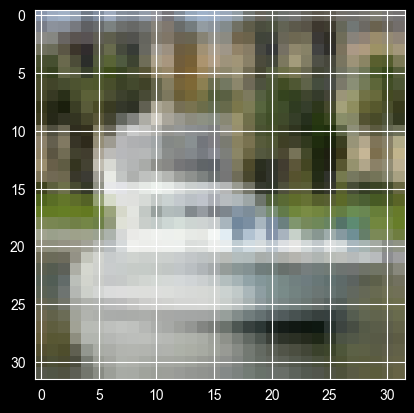

In [60]:
plt.imshow(X_test[22],cmap="Blues")

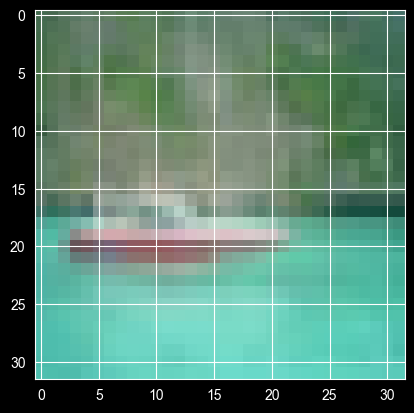

In [61]:
plt.imshow(X_test[559],cmap="Blues")

In [36]:
len(model.layers)

9

In [72]:
conv1 = model.layers[0]
conv1.weights

weights_1,bias_1 = conv1.get_weights()

In [83]:
conv2 = model.layers[2]
conv2.weights

weights_2,bias_2 = conv2.get_weights()

In [84]:
v_w1= np.transpose(weights_1,(3,0,1,2))
v_w1.shape

(32, 3, 3, 3)

In [85]:
v_w2 = np.transpose(weights_2,(3,0,1,2))
v_w2.shape

(64, 3, 3, 32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1455284..0.16200152].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17503622..0.22012421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20479089..0.18883859].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23826233..0.27358308].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24118723..0.21385577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22196093..0.21243675].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range

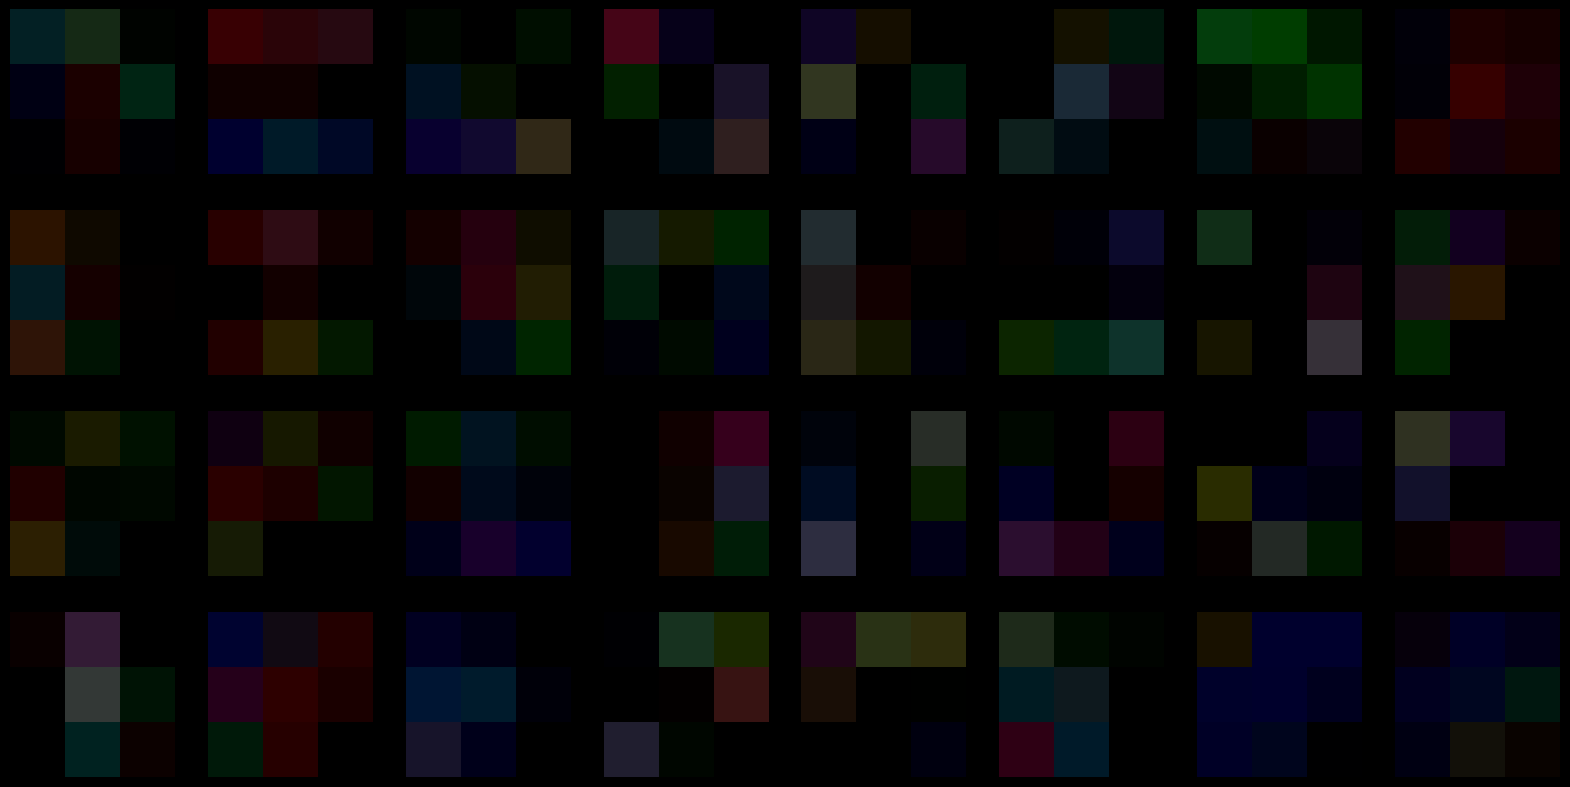

In [86]:
fig, axes = plt.subplots(4,8,figsize=(20,10))
for idx,ax in enumerate(axes.ravel()):
    ax.imshow(v_w1[idx],cmap="gray")
    ax.set_axis_off()

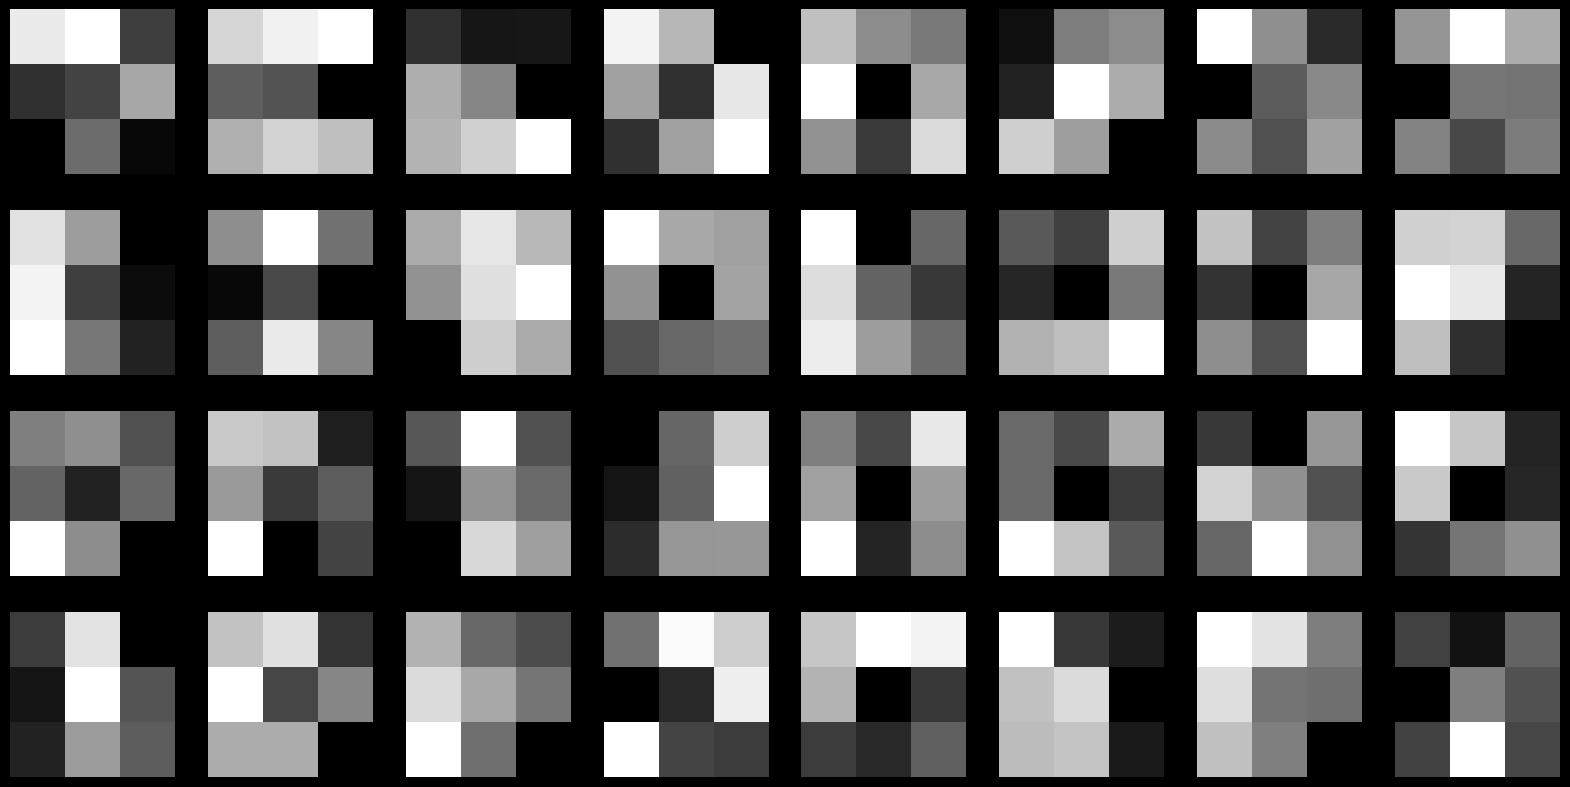

In [93]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for idx, ax in enumerate(axes.ravel()):
    # Option A: Convert the 3-channel kernel to grayscale by averaging
    filter_img = v_w1[idx].mean(axis=-1)

    # Normalize to [0, 1] for proper display
    #filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min() + 1e-8)

    #ax.imshow(filter_img, cmap="gray")
    ax.imshow(filter_img,cmap="gray")
    ax.set_axis_off()